# Statistics 1

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

**Lecture:** 9 — Oct 13

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3b_Statistics_1.ipynb)

This notebook covers:

1. Describing relationships between variables: covariance and correlation
2. Hypothesis testing and confidence intervals (t-test, ANOVA, paired t-test)
3. Two kinds of mistake: Type I and Type II errors

Big theme:

> The Central Limit Theorem told us the sample mean is approximately Gaussian with spread $\sigma/\sqrt{n}$. Statistics turns that fact into decisions — quantifying relationships, attaching uncertainty to estimates, and testing whether an effect is larger than sampling noise. A small p-value means the data are unlikely under the null — not that the null is false.

In [1]:
# Setup

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Visualization Helpers

In [2]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def show_widget_or_fallback(widget_fn, fallback_fn):
    """Try to show an ipywidgets interaction; otherwise run a static fallback."""
    try:
        import ipywidgets as widgets
        from IPython.display import display

        display(widget_fn(widgets))
    except Exception as e:
        print("Interactive widgets are not available in this environment.")
        print("Running a static example instead.")
        fallback_fn()
        print(e)

### Data Setup
Load the penguins dataset used throughout this notebook.

In [3]:
penguins = sns.load_dataset("penguins").dropna()

## Describing Relationships: Covariance and Correlation

In the Probability notebook we described a *single* random variable by its
expectation and variance. Most data, though, come with several variables at once,
and the first statistical question is usually: **do they move together?**

### Covariance

For **two random variables** $X$ and $Y$, the **covariance** generalizes variance
to a pair:

$$
\mathrm{Cov}(X, Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])].
$$

- If $\mathrm{Cov}(X, Y) > 0$, large values of $X$ tend to go with large values of $Y$.
- If $\mathrm{Cov}(X, Y) < 0$, large values of $X$ tend to go with small values of $Y$.
- If $\mathrm{Cov}(X, Y) \approx 0$, there may be no linear relationship.

**Example.** Height and the chance of playing in the NBA tend to move together, since taller people are more likely to play, so their covariance is positive. By contrast, a car's mileage and its resale price move in opposite directions, because higher mileage generally means a lower price, so their covariance is negative.

Note that the covariance of a variable with itself is just its variance: $\mathrm{Cov}(X, X) = \mathrm{Var}(X)$.

### Correlation

The **correlation** is a normalized version of covariance:

$$
\rho_{X,Y} = \frac{\mathrm{Cov}(X, Y)}{\sqrt{\mathrm{Var}(X)\,\mathrm{Var}(Y)}}.
$$

It takes values in $[-1, 1]$ and is easier to compare across different variable scales. We will mostly estimate covariance and correlation from data.


### Example: Simulating correlated variables


Sample covariance: 1.6674330144358414
Sample correlation: 0.9605512511701902


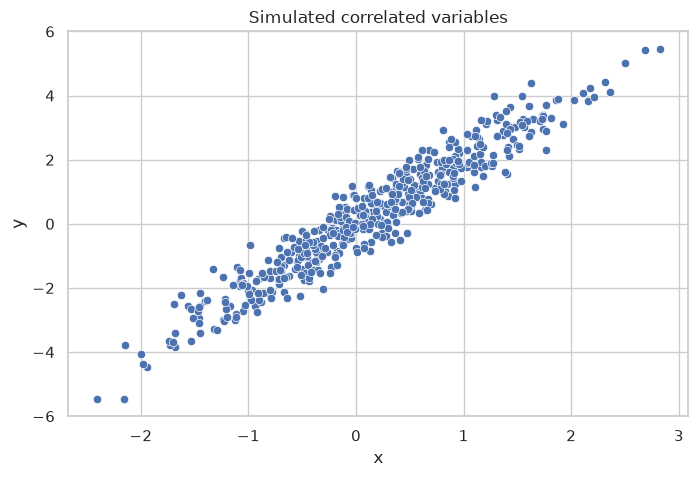

In [4]:
# Simulate two correlated variables
n = 500
x = np.random.normal(0, 1, size=n)
noise = np.random.normal(0, 0.5, size=n)
y = 2 * x + noise  # y is roughly a linear function of x

print("Sample covariance:", np.cov(x, y, bias=False)[0, 1])
print("Sample correlation:", np.corrcoef(x, y)[0, 1])

sns.scatterplot(x=x, y=y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated correlated variables")
plt.show()

#### Coding Challenge:

You can modify the relationship between `x` and `y` above (e.g., change the slope or noise level) and see how the covariance and correlation change.

### Correlation in a real dataset

We will look at relationships between the numeric features of the `penguins` dataset.


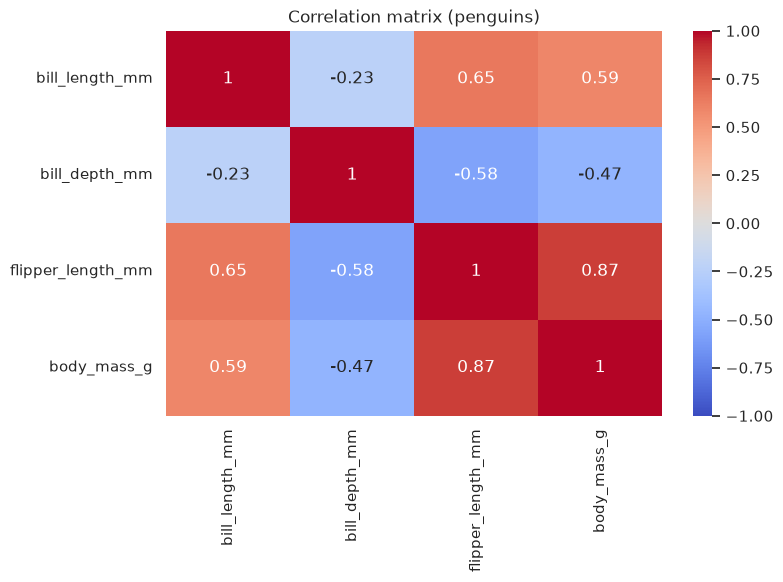

In [5]:
#| code-fold: true
numeric_cols = penguins.select_dtypes(include=[np.number]).columns
corr = penguins[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix (penguins)")
plt.show()

#### Coding Challenge:
Look at the correlation matrix. Which pairs of variables appear to be most strongly related? Which are weakly related?


### Visual Exercise: Beyond the Correlation Matrix

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3b_Statistics_1.ipynb#scrollTo=ex-beyond-correlation-matrix)

A correlation matrix gives a compact summary, but it can hide important structure.

A scatterplot matrix lets us see relationships, outliers, clusters, and nonlinear patterns.


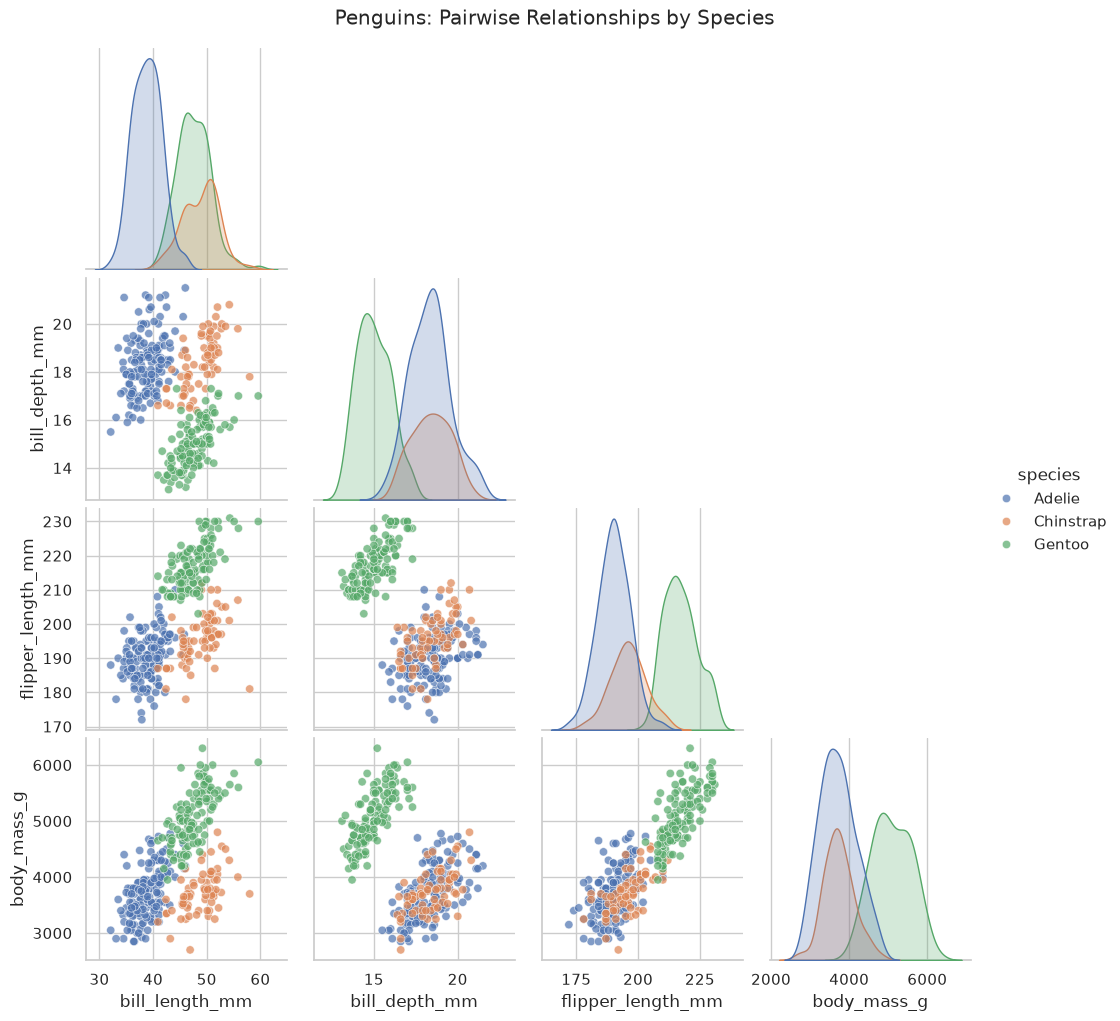

In [6]:
sns.pairplot(
    penguins,
    vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
    hue="species",
    corner=True,
    plot_kws={"alpha": 0.7},
)
plt.suptitle("Penguins: Pairwise Relationships by Species", y=1.02)
plt.show()

#### Exercise: Correlation Plus Context

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3b_Statistics_1.ipynb#scrollTo=ex-correlation-plus-context)

Choose one pair of variables from the pairplot.

1. Is the relationship positive, negative, or weak?
2. Does the relationship look the same within each species?
3. Is the overall correlation possibly influenced by species differences?
4. What would be misleading about reporting only one correlation number?


## Hypothesis Testing and Confidence Intervals

Covariance and correlation *describe* the data in front of us. But we usually want
to reach past the sample to the population it came from: is an observed difference
**real**, or just the sampling noise the Central Limit Theorem taught us to
expect? That leap — from description to inference — is hypothesis testing.

### Framing a question

Suppose we want to know whether two groups differ in some numeric variable. For example:

- Do Adelie and Gentoo penguins have different mean body mass?

We can formalize this as a **hypothesis test**:

- Null hypothesis $H_0$: the two groups have the same mean body mass.
- Alternative hypothesis $H_1$: the group means are different.

::: {.callout-warning title="A subtle but important point"}
Hypothesis testing is asymmetric: it can only ever cast doubt on $H_0$, it never *proves* $H_1$ true.

- When we "reject $H_0$," we are really saying: *the data we observed would be very unlikely if $H_0$ were true.* So we treat $H_0$ as implausible and act as if $H_1$ holds, but this is a probabilistic judgment, not a proof. There is always some chance we are wrong.
- When we "fail to reject $H_0$," it does **not** mean $H_0$ is true. It only means we did not gather enough evidence to rule it out. Absence of evidence is not evidence of absence, perhaps the effect is real but our sample was too small to detect it.

In short: we never confirm a hypothesis, we only find that the data are or are not compatible with $H_0$. The whole framework is built around trying to *disprove* the null, not to *prove* the alternative.
:::



### Test statistics and p-values

A **test statistic** is a number that summarizes how different the groups are (for example, the difference in sample means).

The **p-value** is:

> The probability, under the null hypothesis $H_0$, of observing a test statistic as extreme as (or more extreme than) the one we observed.

It does **not** tell us the probability that the null hypothesis is true.

**How does this connect to 3.1?** In 3.1 we said we reject $H_0$ when the observed difference is "large enough to be unlikely under $H_0$." The p-value is exactly how we make "unlikely" precise. A **small p-value** means: *if the groups really had the same mean, we would almost never see a difference this large just by chance.* So the smaller the p-value, the stronger the evidence **against** $H_0$, and the more comfortable we are keeping $H_1$.

**A concrete example.** Suppose we measure many Adelie and Gentoo penguins and find the Gentoos are on average 900 g heavier, with a p-value of 0.001. This means: *if the two species truly had the same mean body mass, a difference this large (or larger) would happen only about 1 time in 1000 by random sampling.* That is unlikely enough that we reject $H_0$ and conclude the species differ in body mass. If instead the p-value had been 0.40, a difference that size would be quite common by chance alone, so we would have no reason to reject $H_0$.

**Decide the threshold *before* you look at the data.** To turn a p-value into a decision, we compare it to a **significance level** $\alpha$ (commonly 0.05, 0.01, or 0.001): we reject $H_0$ when $p < \alpha$.

::: {.callout-warning title="Choose α before collecting the data"}
The significance level is the threshold of "unlikeliness" you require before you are willing to reject $H_0$, and it must be fixed *in advance*. If you collect the data first and then pick $\alpha$ (or keep testing until something looks significant), you can almost always manufacture a "significant" result by chance. Setting $\alpha$ up front keeps the test honest.
:::


### Two kinds of mistake: Type I and Type II errors

Because a test is a *decision under uncertainty*, it can be wrong in two different
ways. Whatever we decide, the truth about $H_0$ is fixed but unknown, so there are
four possible outcomes:

| | $H_0$ is true | $H_0$ is false |
|---|---|---|
| **Reject $H_0$** | ❌ Type I error (false positive) | ✅ correct — a true effect detected |
| **Fail to reject $H_0$** | ✅ correct | ❌ Type II error (false negative) |

- A **Type I error** is declaring an effect that is not real. This is exactly the
  risk we control with the significance level: $\alpha = P(\text{reject } H_0 \mid H_0 \text{ true})$.
  Choosing $\alpha = 0.05$ means we accept a 5% chance of a false positive.
- A **Type II error** is *missing* a real effect. Its probability is called
  $\beta = P(\text{fail to reject } H_0 \mid H_0 \text{ false})$.
- The **power** of a test is $1 - \beta$: the probability of detecting an effect
  that is genuinely there.

This reframes an earlier warning. When we "fail to reject $H_0$," we are not
proving $H_0$ — we may simply have too little power to see a real effect (a Type II
error). Small samples and noisy measurements both drain power. We *quantify* power
in the next notebook, and the same false-positive / false-negative distinction
returns in supervised learning as the false positives and false negatives of a
confusion matrix.


### Confidence intervals

A **confidence interval** is a range of plausible values for a parameter (for example, the true mean difference). A 95% confidence interval can be interpreted (informally) as:

> If we repeated this whole data-collection process many times and built a 95% CI each time, about 95% of those intervals would contain the true parameter.

**Back to the penguins.** Suppose our data give a 95% confidence interval of $[750\text{ g},\ 1050\text{ g}]$ for the difference in mean body mass between Gentoo and Adelie penguins. This says that the values between 750 g and 1050 g are all plausible estimates of the true difference.

> **CIs and p-values are two views of the same evidence.** A 95% confidence interval that excludes the null value corresponds to a p-value below $\alpha = 0.05$ (indeed, $95\%=0.95=1-0.05=1-\alpha)$). The confidence interval is often more informative, though, because it shows not just *whether* there is a difference but also *how big* it plausibly is.


### Example: Do two penguin species have different body mass?


In [7]:
# Subset to two species for simplicity
subset = penguins[penguins["species"].isin(["Adelie", "Gentoo"])].copy()

adelie = subset[subset["species"] == "Adelie"]["body_mass_g"]
gentoo = subset[subset["species"] == "Gentoo"]["body_mass_g"]

print("Adelie mean mass:", adelie.mean())
print("Gentoo mean mass:", gentoo.mean())

# Two-sample t-test (assuming unequal variances)
t_stat, p_val = stats.ttest_ind(adelie, gentoo, equal_var=False)
print("p-value:", p_val)

Adelie mean mass: 3706.1643835616437
Gentoo mean mass: 5092.436974789916
p-value: 1.2231704192566996e-63


#### Questions

Using the output of the cell above, answer the following:

1. **Read the result.** What is the p-value? Using a significance level of $\alpha = 0.05$, do you reject or fail to reject $H_0$? State your conclusion in one plain-English sentence about the penguins.

2. **Interpret the p-value correctly.** A classmate says: _"The p-value is the probability that the two species have the same mean body mass."_ Explain why this statement is wrong, and give the correct interpretation.

3. **Sample size thought experiment.** Suppose you had measured only 5 penguins per species instead of the full dataset. Would you expect the p-value to be larger or smaller, all else equal? Connect your answer to the idea of "failing to reject $H_0$" from Section 3.1.


We can also build a simple confidence interval for the **difference in means**:

$$
\Delta = \mu_{\text{Gentoo}} - \mu_{\text{Adelie}}.
$$


In [8]:
# Compute a 95% CI for the difference in means using a normal approximation

diff_mean = gentoo.mean() - adelie.mean()

se_adelie = adelie.std(ddof=1) / np.sqrt(len(adelie))
se_gentoo = gentoo.std(ddof=1) / np.sqrt(len(gentoo))
se_diff = np.sqrt(se_adelie**2 + se_gentoo**2)

z = 1.96  # approx 97.5th percentile of standard normal
ci_low = diff_mean - z * se_diff
ci_high = diff_mean + z * se_diff

print("Difference in means (Gentoo - Adelie):", diff_mean)
print("Approx 95% CI for difference:", (ci_low, ci_high))

Difference in means (Gentoo - Adelie): 1386.2725912282726
Approx 95% CI for difference: (np.float64(1269.4280436730803), np.float64(1503.117138783465))


#### Visualizing a Confidence Interval

A confidence interval is easier to interpret when we plot it against the null value of 0.

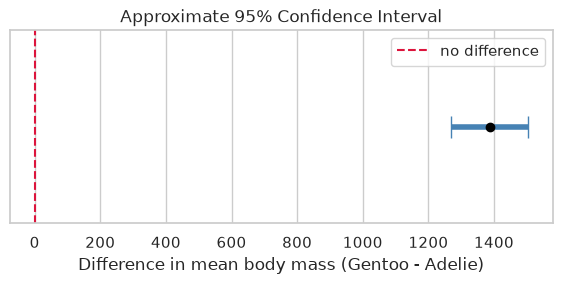

In [9]:
plt.figure(figsize=(7, 2.5))
plt.errorbar(
    x=diff_mean,
    y=0,
    xerr=[[diff_mean - ci_low], [ci_high - diff_mean]],
    fmt="o",
    color="black",
    ecolor="steelblue",
    elinewidth=4,
    capsize=8,
)
plt.axvline(0, color="crimson", linestyle="--", label="no difference")
plt.yticks([])
plt.xlabel("Difference in mean body mass (Gentoo - Adelie)")
plt.title("Approximate 95% Confidence Interval")
plt.legend()
plt.show()

#### Questions

Look at the confidence interval plotted above and answer the following:

1. **Read the plot.** Roughly what range does the interval cover? What does the black dot represent, and what do the two ends of the blue bar represent?

2. **The dashed red line.** The plot marks 0 with a dashed "no difference" line. Where does this line fall relative to the interval, inside it or outside it? What does that position tell you about $H_0$?

3. **Connect to the t-test.** In the previous cell you obtained a p-value. Is the conclusion you draw from this plot (does the interval cross 0?) consistent with the conclusion you drew from the p-value at $\alpha = 0.05$? Explain why the two should agree.

4. **Width of the interval.** What does the *width* of the interval tell you that the p-value does not? Describe one change to the data (e.g. more penguins measured, or noisier measurements) that would make this interval narrower or wider.



#### Response:

Write your interpretation here.


### A closer look at the t-test

A **t-test** is a statistical method for asking whether two groups have different means.

We frame the question like this:

- Null hypothesis $H_0$: The groups come from populations with the **same mean**
- Alternative hypothesis $H_1$: Their means are different

For two independent groups, the **test statistic** is:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{SE(\bar{x}_1 - \bar{x}_2)}
$$

where:

- $\bar{x}_1, \bar{x}_2$ = sample means
- $SE(\bar{x}_1 - \bar{x}_2)$ = standard error of the difference in means

If the null hypothesis is true, the statistic follows a **t-distribution**, so:

- Large $|t|$ means the groups are very different
- Small $|t|$ means differences could just be random variation

---

### Types of Two-Sample t-tests

1. **Welch's t-test** (default in most data science practice)
   - Assumes:
     - Groups are independent
     - Data are roughly symmetric / not extremely skewed
   - Does *not* assume equal variances
   - This is what `scipy.stats.ttest_ind(equal_var=False)` computes

2. **Pooled-variance t-test**
   - Assumes equal variance between groups
   - Often unrealistic in practice

---

### From the t-statistic to the p-value

The t-statistic and the p-value are really two steps of the same idea.

First we compute $t$, which measures how big the difference in means is compared to the noise. Then we ask: **if $H_0$ were true, how often would we see a $t$ this large just by chance?**

If $H_0$ is true, $t$ is usually close to 0, and large values of $|t|$ are rare. The **p-value** is the probability of getting a $t$ at least as extreme as ours, assuming $H_0$ is true.

So the connection is simple:

- **Large $|t|$ → small p-value** → strong evidence against $H_0$
- **Small $|t|$ → large p-value** → data are consistent with $H_0$

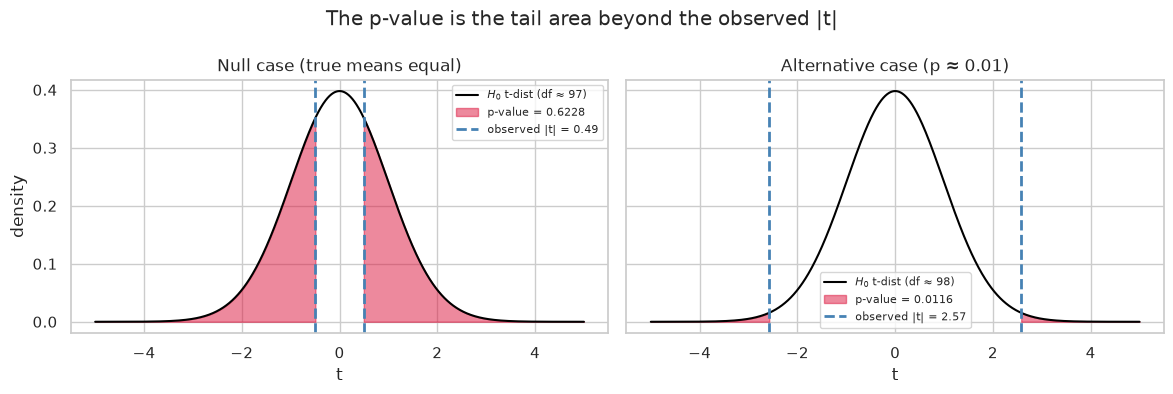

In [10]:
# Compare the p-value (tail area) for the null vs a significant alternative, side by side
rng = np.random.default_rng(0)
n = 50

# Null case: means equal
g1_null = rng.normal(0, 1, n)
g2_null = rng.normal(0, 1, n)

# Alternative case: difference tuned so p ≈ 0.01
g1_alt = rng.normal(0, 1, n)
g2_alt = rng.normal(0.65, 1, n)


def plot_pvalue(ax, x_data, y_data, title):
    res = stats.ttest_ind(x_data, y_data, equal_var=False)
    t_obs, p_obs, df = res.statistic, res.pvalue, res.df
    t_abs = abs(t_obs)

    x = np.linspace(-5, 5, 1000)
    y = stats.t.pdf(x, df)

    ax.plot(x, y, color="black", label=f"$H_0$ t-dist (df ≈ {df:.0f})")
    ax.fill_between(x, y, where=(x >= t_abs), color="crimson", alpha=0.5)
    ax.fill_between(
        x,
        y,
        where=(x <= -t_abs),
        color="crimson",
        alpha=0.5,
        label=f"p-value = {p_obs:.4f}",
    )

    # dashed lines at +|t| and -|t| (the two-sided cutoffs)
    ax.axvline(
        t_abs,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label=f"observed |t| = {t_abs:.2f}",
    )
    ax.axvline(-t_abs, color="steelblue", linestyle="--", linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("t")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_pvalue(axes[0], g1_null, g2_null, "Null case (true means equal)")
plot_pvalue(axes[1], g1_alt, g2_alt, "Alternative case (p ≈ 0.01)")
axes[0].set_ylabel("density")
fig.suptitle("The p-value is the tail area beyond the observed |t|")
plt.tight_layout()
plt.show()

### Visual intuition: overlapping vs separated distributions

If two groups truly differ in mean:

- Their distributions will be separated
- The t-statistic tends to be larger
- p-value tends to be smaller

If they overlap heavily:

- the difference could easily be due to chance
- p-value is likely large


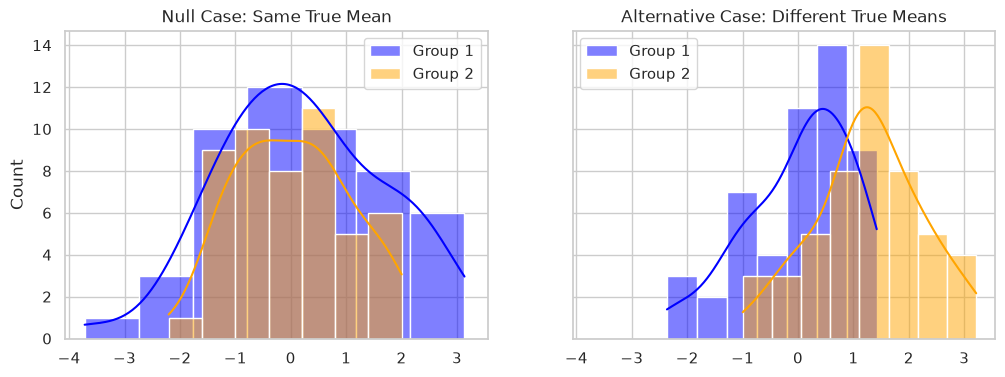

In [11]:
#| code-fold: true
# Regenerate the two scenarios (same seed / shift as the p-value illustration)
rng = np.random.default_rng(0)
n = 50

# Null case: same true mean
group1_null = rng.normal(0, 1.6, n)
group2_null = rng.normal(0, 1, n)

# Alternative case: different true means (shift = 0.65, p ≈ 0.01)
group1_alt = rng.normal(0, 1, n)
group2_alt = rng.normal(1.4, 1, n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

sns.histplot(group1_null, color="blue", label="Group 1", kde=True, ax=axes[0])
sns.histplot(group2_null, color="orange", label="Group 2", kde=True, ax=axes[0])
axes[0].set_title("Null Case: Same True Mean")
axes[0].legend()

sns.histplot(group1_alt, color="blue", label="Group 1", kde=True, ax=axes[1])
sns.histplot(group2_alt, color="orange", label="Group 2", kde=True, ax=axes[1])
axes[1].set_title("Alternative Case: Different True Means")
axes[1].legend()

plt.show()

### Interactive Demo: Effect Size, Sample Size, and p-values

A p-value depends on both the size of the group difference and the amount of uncertainty.

Small effects can become detectable with large samples. Large effects can be hard to detect when samples are small or noisy.


In [12]:
def plot_two_group_test(effect=0.5, n=40, sigma=1.0, seed=2):
    rng = np.random.default_rng(seed)
    group_a = rng.normal(0, sigma, n)
    group_b = rng.normal(effect, sigma, n)
    t, p = stats.ttest_ind(group_a, group_b, equal_var=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.kdeplot(group_a, fill=True, alpha=0.35, label="group A", ax=axes[0])
    sns.kdeplot(group_b, fill=True, alpha=0.35, label="group B", ax=axes[0])
    axes[0].axvline(group_a.mean(), color="steelblue", linestyle="--")
    axes[0].axvline(group_b.mean(), color="darkorange", linestyle="--")
    axes[0].set_title("Observed group distributions")
    axes[0].legend()

    axes[1].bar(
        ["A", "B"],
        [group_a.mean(), group_b.mean()],
        yerr=[group_a.std(ddof=1) / np.sqrt(n), group_b.std(ddof=1) / np.sqrt(n)],
        capsize=8,
        color=["steelblue", "darkorange"],
    )
    axes[1].set_title(f"Means +/- SE\nt = {t:.2f}, p = {p:.4f}")
    axes[1].set_ylabel("mean")

    plt.tight_layout()
    plt.show()


def pvalue_widget(widgets):
    return widgets.interactive(
        plot_two_group_test,
        effect=widgets.FloatSlider(
            value=0.5, min=0.0, max=2.0, step=0.05, description="effect"
        ),
        n=widgets.IntSlider(value=40, min=5, max=300, step=5, description="n"),
        sigma=widgets.FloatSlider(
            value=1.0, min=0.2, max=3.0, step=0.1, description="sigma"
        ),
        seed=widgets.IntSlider(value=2, min=0, max=30, step=1, description="seed"),
    )


show_widget_or_fallback(
    pvalue_widget, lambda: plot_two_group_test(effect=0.5, n=40, sigma=1.0, seed=2)
)

interactive(children=(FloatSlider(value=0.5, description='effect', max=2.0, step=0.05), IntSlider(value=40, de…

#### Exercise: What Makes Evidence Stronger?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3b_Statistics_1.ipynb#scrollTo=ex-what-makes-evidence-stronger)

Use the sliders.

1. Hold `effect` fixed and increase `n`. What tends to happen to the p-value?
2. Hold `n` fixed and increase `sigma`. What tends to happen?
3. Find a case where the effect is real but the p-value is not small.
4. Why is a p-value not the same thing as effect size?


### Where t-tests come from: a callback to the CLT

Everything in this section rests on the **sampling distribution** — how a statistic
like the difference in means would vary if we repeated the whole data collection.
We built that idea in the Probability notebook: the Central Limit Theorem showed
that the sample mean is approximately Gaussian, and that its spread is the standard
error

$$
SE = \frac{\sigma}{\sqrt{n}}.
$$

That is exactly why the t-test works the way it does:

- larger $n$ shrinks the standard error, so confidence intervals get tighter and
  tests become more **powerful**;
- the t-statistic asks how large our observed difference is *relative to* this
  sampling variability.

So the t-test is not a new idea — it is the CLT put to work on a difference in
means.


#### Coding Challenge:

Compute t-test, p-values for comparison between Chinstrap and Adelie

### One-Way ANOVA: Comparing More Than Two Groups

So far, we compared **two groups** using a t-test.

What if we have **three or more groups** and want to know:

> "Do at least one of these group means differ from the others?"

Example question:

- Do different penguin species have different mean body mass?

For this, we can use a **one-way ANOVA** (Analysis of Variance).

- Null hypothesis $H_0$: all group means are equal
  $$
  \mu_1 = \mu_2 = \dots = \mu_k
  $$
- Alternative hypothesis $H_1$: at least one mean is different

ANOVA uses an **F-statistic**:

$$
F = \frac{\text{variance between groups}}{\text{variance within groups}}.
$$

- If between-group variation is large relative to within-group variation, $F$ is large, and we get a small p-value.


In [13]:
from scipy.stats import f_oneway

# Use all species that are present
species_groups = []
labels = []

for species_name, grp in penguins.groupby("species"):
    if "body_mass_g" in grp:
        species_groups.append(grp["body_mass_g"].dropna().values)
        labels.append(species_name)

print("Species included:", labels)

# Run one-way ANOVA
F_stat, p_val_anova = f_oneway(*species_groups)

print(f"F-statistic: {F_stat:,.2f}")
print(f"p-value:     {p_val_anova:.3e}")

Species included: ['Adelie', 'Chinstrap', 'Gentoo']
F-statistic: 341.89
p-value:     3.745e-81


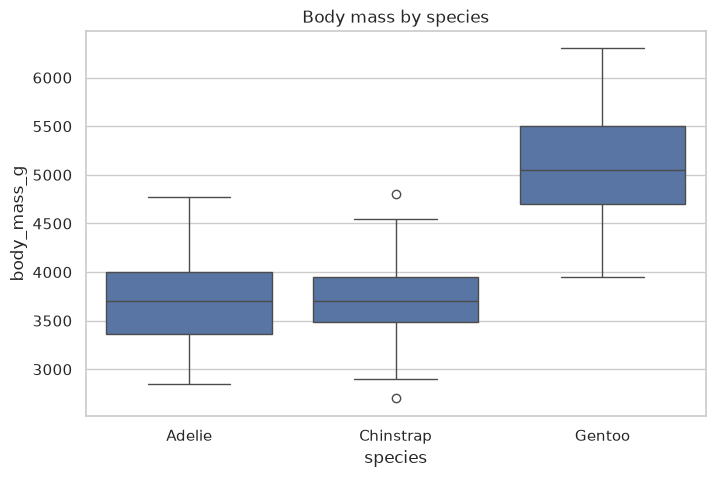

In [14]:
#| code-fold: true
sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.title("Body mass by species")
plt.show()

#### Interpretation:
- The ANOVA p-value tells us whether there is **evidence that not all means are equal**.
- It does **not** tell us *which* groups differ.
- For that, we might do follow-up pairwise comparisons (t-tests with correction), or look at plots.

In this course, the main point is conceptual:

- ANOVA is a generalization of the two-sample t-test to more than two groups.
- It still relies on the same basic idea: signal (between-group differences) vs noise (within-group variability).


### Paired t-test: Before/After Measurements

Sometimes we take **two measurements on the same unit**, so the observations come in natural pairs:

- a patient's blood pressure **before vs. after** taking a medication
- the **left vs. right** flipper length of the same penguin
- a student's exam score **before vs. after** a tutoring session
- a city's air-quality reading on the **same day, one year apart**

Here the observations are **paired**: each "before" value belongs with a corresponding "after" value from the *same* subject. Because both measurements share that subject's individual quirks (a naturally fast runner is fast both times), pairing **cancels out** that person-to-person variation and lets us focus on the *change*.

We want to know:

> Is the **average change** different from zero?

We can use a **paired t-test**.

- Null hypothesis $H_0$: the mean difference is zero
- Alternative hypothesis $H_1$: the mean difference is not zero

The trick is to reduce each pair to a single number — its difference:

$$
d_i = \text{after}_i - \text{before}_i
$$

Then we run a **one-sample t-test on the $d_i$**, checking whether their mean differs from 0:

$$
t = \frac{\bar{d}}{s_d / \sqrt{n}}
$$

where $\bar{d}$ is the mean of the differences, $s_d$ their standard deviation, and $n$ the number of pairs. Under $H_0$ this follows a t-distribution with $n - 1$ degrees of freedom.


In [15]:
rng = np.random.default_rng(123)

n_subjects = 30

# Simulate "before" scores
before = rng.normal(loc=70, scale=8, size=n_subjects)

# Simulate improvement: small true effect + noise
true_improvement = 5.0
after = before + true_improvement + rng.normal(loc=0, scale=5, size=n_subjects)

diffs = after - before

print("Mean before:", before.mean())
print("Mean after:", after.mean())
print("Mean difference (after - before):", diffs.mean())

Mean before: 71.77789852951595
Mean after: 76.62026034754948
Mean difference (after - before): 4.842361818033538


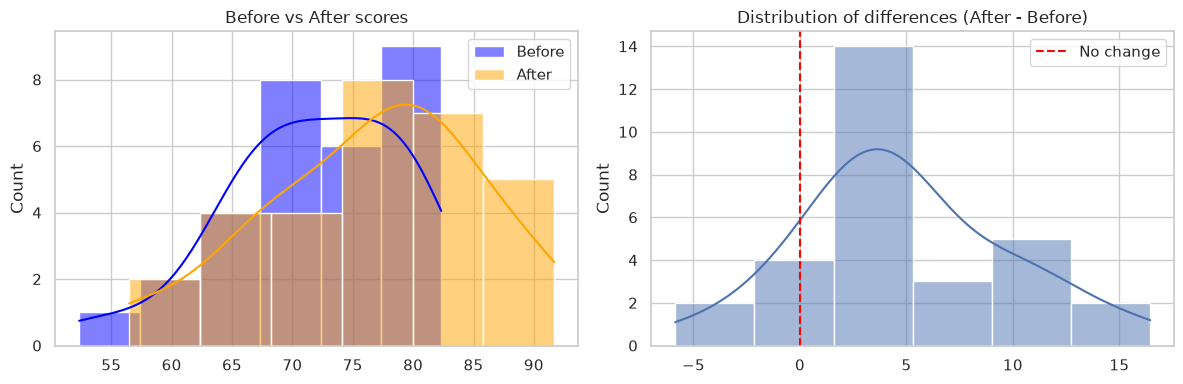

In [16]:
#| code-fold: true
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Side-by-side distributions
sns.histplot(before, kde=True, ax=ax[0], color="blue", label="Before")
sns.histplot(after, kde=True, ax=ax[0], color="orange", label="After")
ax[0].set_title("Before vs After scores")
ax[0].legend()

# Differences
sns.histplot(diffs, kde=True, ax=ax[1])
ax[1].axvline(0, color="red", linestyle="--", label="No change")
ax[1].set_title("Distribution of differences (After - Before)")
ax[1].legend()

plt.tight_layout()
plt.show()

### Visualizing Paired Data

For paired measurements, the connection between before and after values matters.

A paired-line plot shows whether most individuals moved in the same direction.


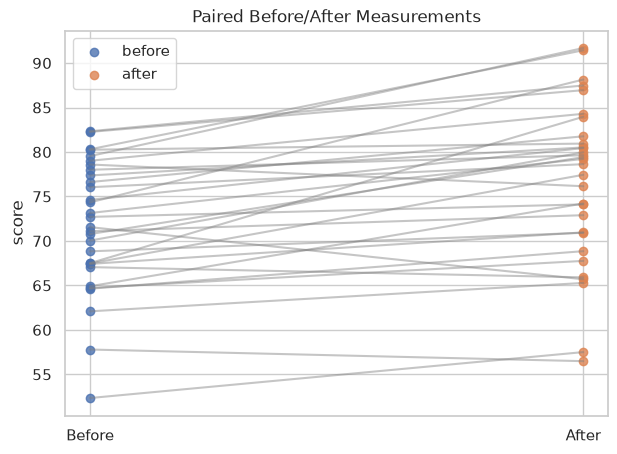

Paired t-test: t = 5.357, p = 0.00001


In [17]:
#| code-fold: true
plt.figure(figsize=(7, 5))
for i in range(n_subjects):
    plt.plot([0, 1], [before[i], after[i]], color="gray", alpha=0.45)
plt.scatter(np.zeros(n_subjects), before, label="before", alpha=0.8)
plt.scatter(np.ones(n_subjects), after, label="after", alpha=0.8)
plt.xticks([0, 1], ["Before", "After"])
plt.ylabel("score")
plt.title("Paired Before/After Measurements")
plt.legend()
plt.show()

paired_t, paired_p = stats.ttest_rel(after, before)
print(f"Paired t-test: t = {paired_t:.3f}, p = {paired_p:.5f}")

Key idea:

- The paired t-test uses **within-subject differences**, which removes some between-person variability.
- This often makes it more sensitive than a two-sample t-test on before/after groups treated as independent.
- Whenever data are naturally paired, we should use a method that respects that structure.


#### Exercise:

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3b_Statistics_1.ipynb#scrollTo=ex-exercise)


In [18]:
from scipy.stats import ttest_ind

# Select the two species
adelie = penguins[penguins["species"] == "Adelie"]["body_mass_g"].dropna()
chinstrap = penguins[penguins["species"] == "Chinstrap"]["body_mass_g"].dropna()

print(f"Adelie samples: {len(adelie)}")
print(f"Chinstrap samples: {len(chinstrap)}")
print(f"Adelie mean: {adelie.mean():.2f} g")
print(f"Chinstrap mean: {chinstrap.mean():.2f} g")

# Welch's t-test (do NOT assume equal variances)
t_stat, p_val = ttest_ind(adelie, chinstrap, equal_var=False)

print("\nWelch Two-Sample t-test")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_val:.6f}")

Adelie samples: 146
Chinstrap samples: 68
Adelie mean: 3706.16 g
Chinstrap mean: 3733.09 g

Welch Two-Sample t-test
t-statistic: -0.448
p-value:     0.654833


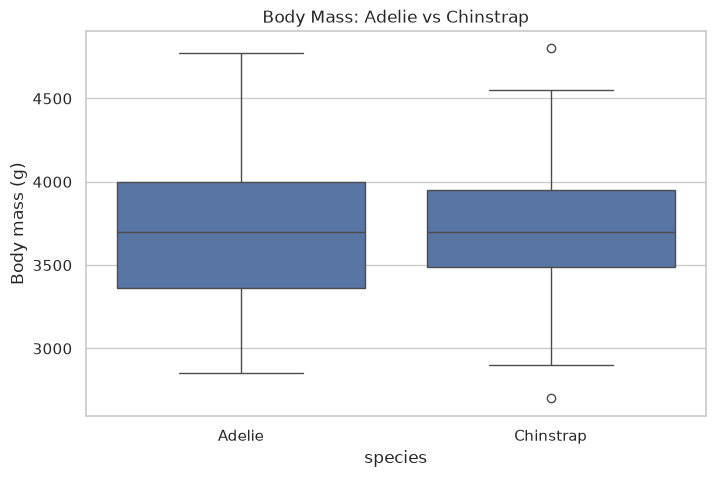

In [19]:
#| code-fold: true
sns.boxplot(
    data=penguins[penguins["species"].isin(["Adelie", "Chinstrap"])],
    x="species",
    y="body_mass_g",
)

plt.title("Body Mass: Adelie vs Chinstrap")
plt.ylabel("Body mass (g)")
plt.show()